In [2]:
import pandas as pd
import numpy as np
import re
from google.colab import files

print("==================================================")
print(" PROSES DATA CLEANING - SKRIPSI PASAR MOBIL OLX")
print("==================================================\n")

# 1. Membaca dataset mentah
print("[1] Membaca data mentah (DataScrappingOLX.csv)...")
df = pd.read_csv('/content/DataScrappingOLX.csv', low_memory=False)
print(f"    Jumlah baris awal: {df.shape[0]} baris")

# 2. Menghapus data duplikat dan data tanpa Harga
print("\n[2] Menghapus data duplikat & memvalidasi kolom harga...")
df = df.drop_duplicates(subset=['URL'])
df = df.dropna(subset=['Harga'])

# 3. Membersihkan kolom 'Harga' (Konversi teks ke Numerik)
print("\n[3] Standardisasi kolom Harga menjadi numerik murni...")
df['Harga'] = df['Harga'].astype(str).str.replace(r'[^\d]', '', regex=True)
df['Harga'] = pd.to_numeric(df['Harga'], errors='coerce')
df = df.dropna(subset=['Harga'])

# 4. Membersihkan kolom 'Kilometer' (Mengambil nilai rata-rata dari rentang)
print("\n[4] Memformat rentang Kilometer menjadi nilai numerik tunggal...")
def clean_km(km_str):
    if pd.isna(km_str):
        return np.nan
    km_str = str(km_str).replace('.', '').replace(',', '')
    numbers = re.findall(r'\d+', km_str)
    if len(numbers) >= 2:
        return (int(numbers[0]) + int(numbers[1])) / 2
    elif len(numbers) == 1:
        return int(numbers[0])
    return np.nan

df['Kilometer'] = df['Kilometer'].apply(clean_km)

# 5. Memfilter 'Lokasi' (Hanya Wilayah Jabodetabek)
print("\n[5] Menyaring data lokasi khusus wilayah Jabodetabek...")
jabodetabek = ['jakarta', 'bogor', 'depok', 'tangerang', 'bekasi']
pattern = '|'.join(jabodetabek)
df['Lokasi'] = df['Lokasi'].astype(str)
df = df[df['Lokasi'].str.lower().str.contains(pattern, na=False)]

# 6. Memastikan 'Tahun' menjadi format angka
df['Tahun'] = pd.to_numeric(df['Tahun'], errors='coerce')

# 7. Standardisasi Nilai Kolom TRANSMISI
print("\n[6] Standardisasi kategori Transmisi (Manual / Automatic)...")
mapping_transmisi = {
    r'(?i).*automatic.*': 'Automatic',
    r'(?i).*otomatis.*': 'Automatic',
    r'(?i).*manual.*': 'Manual'
}
df['Transmisi'] = df['Transmisi'].astype(str).replace(mapping_transmisi, regex=True)

# 8. Standardisasi Nilai Kolom BAHAN BAKAR
print("\n[7] Standardisasi kategori Bahan Bakar...")
mapping_bbm = {
    r'(?i).*petrol.*': 'Bensin',
    r'(?i).*bensin.*': 'Bensin',
    r'(?i).*diesel.*': 'Diesel',
    r'(?i).*hybrid.*': 'Hybrid',
    r'(?i).*listrik.*': 'Listrik'
}
df['Bahan Bakar'] = df['Bahan Bakar'].astype(str).replace(mapping_bbm, regex=True)

# =====================================================================
# 9. FILTER KETAT (MENGHAPUS IKLAN NON-MOBIL: RUMAH, MOTOR, DLL)
# =====================================================================
print("\n[8] Filter Ketat: Menghapus iklan non-mobil dan data tidak lengkap...")
valid_brands = [
    'Toyota', 'Honda', 'Mercedes-Benz', 'Mitsubishi', 'Nissan', 'Daihatsu',
    'Mazda', 'Suzuki', 'Bmw', 'Hyundai', 'Wuling', 'Lexus', 'Kia', 'Chevrolet',
    'Mini', 'Ford', 'Volkswagen', 'Byd', 'Land', 'Chery', 'Isuzu', 'Datsun',
    'Peugeot', 'Jeep', 'Subaru', 'Volvo', 'Audi'
]

# Ambil hanya merek mobil yang valid (mengabaikan huruf besar/kecil)
df = df[df['Merk Mobil'].str.title().isin([b.title() for b in valid_brands])]

# Hapus baris jika kolom esensialnya (Tahun, KM, Transmisi, BBM) kosong
df = df.dropna(subset=['Harga', 'Tahun', 'Kilometer', 'Transmisi', 'Bahan Bakar'])
# =====================================================================

# Reset index tabel
df = df.reset_index(drop=True)

print("\n==================================================")
print(" RINGKASAN HASIL DATA CLEANING")
print("==================================================")
print(f"Total Baris Akhir     : {df.shape[0]} Baris (Valid 100% Mobil)")
print(f"Total Kolom           : {df.shape[1]} Kolom")
print("Pengecekan Missing Values (Data Kosong) pada kolom utama:")
print(df[['Harga', 'Tahun', 'Kilometer', 'Transmisi', 'Bahan Bakar']].isna().sum())

# 10. Menyimpan dan mengunduh hasil akhir
output_file = 'Data_OLX_SuperClean.csv'
df.to_csv(output_file, index=False)
print(f"\n[9] Berhasil menyimpan file {output_file}! Mengunduh...")
files.download(output_file)


 PROSES DATA CLEANING - SKRIPSI PASAR MOBIL OLX

[1] Membaca data mentah (DataScrappingOLX.csv)...
    Jumlah baris awal: 20001 baris

[2] Menghapus data duplikat & memvalidasi kolom harga...

[3] Standardisasi kolom Harga menjadi numerik murni...

[4] Memformat rentang Kilometer menjadi nilai numerik tunggal...

[5] Menyaring data lokasi khusus wilayah Jabodetabek...

[6] Standardisasi kategori Transmisi (Manual / Automatic)...

[7] Standardisasi kategori Bahan Bakar...

[8] Filter Ketat: Menghapus iklan non-mobil dan data tidak lengkap...

 RINGKASAN HASIL DATA CLEANING
Total Baris Akhir     : 18693 Baris (Valid 100% Mobil)
Total Kolom           : 13 Kolom
Pengecekan Missing Values (Data Kosong) pada kolom utama:
Harga          0
Tahun          0
Kilometer      0
Transmisi      0
Bahan Bakar    0
dtype: int64

[9] Berhasil menyimpan file Data_OLX_SuperClean.csv! Mengunduh...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
#filtering data sebelum data untuk analisis k-means clustering

# Harga
df = df[(df['Harga'] >= 10000000) & (df['Harga'] <= 2000000000)]

# Tahun
df = df[(df['Tahun'] >= 2000) & (df['Tahun'] <= 2025)]

# Kilometer
df = df[(df['Kilometer'] <= 500000)]

In [4]:
# Membuat dataset khusus clustering
cluster_data = df[['Harga', 'Tahun', 'Kilometer']]

# Melihat data
cluster_data.head()

,Harga,Tahun,Kilometer
0,200000000,2020.0,87500.0
1,113000000,2019.0,42500.0
2,94500000,2015.0,102500.0
3,89500000,2015.0,140000.0
4,227000000,2021.0,72500.0


In [5]:
# Menampilkan statistik deskriptif variabel clustering
cluster_data.describe()

,Harga,Tahun,Kilometer
count,1.807200e+04,18072.000000,18072.000000
mean,3.003041e+08,2018.559706,63132.099546
std,2.705458e+08,4.514094,48708.206220
min,1.200000e+07,2000.000000,0.000000
25%,1.430000e+08,2016.000000,22500.000000
50%,2.050000e+08,2019.000000,52500.000000
75%,3.530000e+08,2022.000000,92500.000000
max,2.000000e+09,2025.000000,300000.000000


In [6]:
#normalisasi
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

# Mengubah hasil menjadi DataFrame
scaled_df = pd.DataFrame(
    scaled_data,
    columns=['Harga','Tahun','Kilometer']
)

scaled_df.head()

,Harga,Tahun,Kilometer
0,-0.370758,0.319075,0.500297
1,-0.692339,0.097540,-0.423597
2,-0.760721,-0.788598,0.808262
3,-0.779202,-0.788598,1.578174
4,-0.270957,0.540609,0.192332


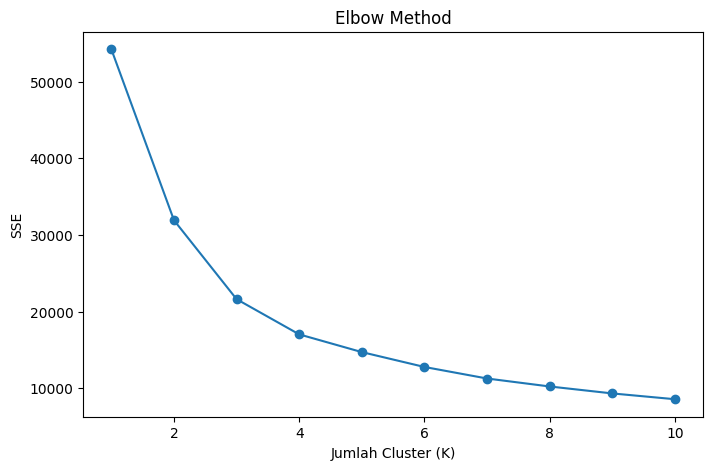

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)

    sse.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), sse, marker='o')

plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('SSE')
plt.title('Elbow Method')

plt.show()

In [8]:
from sklearn.cluster import KMeans

# Membuat model K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Melakukan clustering
cluster = kmeans.fit_predict(scaled_df)

# Menambahkan hasil cluster ke dataset utama
cluster_data['Cluster'] = cluster

# Melihat hasil
cluster_data.head()

/tmp/ipykernel_798/707343077.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['Cluster'] = cluster


,Harga,Tahun,Kilometer,Cluster
0,200000000,2020.0,87500.0,0
1,113000000,2019.0,42500.0,0
2,94500000,2015.0,102500.0,1
3,89500000,2015.0,140000.0,1
4,227000000,2021.0,72500.0,0


In [9]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_df, cluster)

print("Silhouette Score :", round(score,4))

Silhouette Score : 0.4072


In [10]:
#mengetahui jumlah masing-masing cluster

cluster_data['Cluster'].value_counts()

,count
Cluster,
0,10236
1,6101
2,1735


In [11]:
#rata-rata setiap cluster

cluster_data.groupby('Cluster').mean()

,Harga,Tahun,Kilometer
Cluster,,,
0,2.686497e+08,2020.687671,40952.148984
1,1.616112e+08,2013.977053,113929.619079
2,9.747597e+08,2022.119885,15361.671470


In [12]:
#label cluster

cluster_label = {
    1: 'Mobil Murah',
    0: 'Mobil Menengah',
    2: 'Mobil Mahal'
}

cluster_data['Kategori_Mobil'] = cluster_data['Cluster'].map(cluster_label)

/tmp/ipykernel_798/3427285079.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['Kategori_Mobil'] = cluster_data['Cluster'].map(cluster_label)


In [13]:
cluster_data[['Cluster','Kategori_Mobil']].head()

,Cluster,Kategori_Mobil
0,0,Mobil Menengah
1,0,Mobil Menengah
2,1,Mobil Murah
3,1,Mobil Murah
4,0,Mobil Menengah


In [14]:
#menghitung jumlah kendaraan pada masing-masing kategori hasil clustering.

cluster_data['Kategori_Mobil'].value_counts()

,count
Kategori_Mobil,
Mobil Menengah,10236
Mobil Murah,6101
Mobil Mahal,1735


In [15]:
# Pelabelan kategori kendaraan berdasarkan hasil clustering

cluster_data = cluster_data.copy()

cluster_data['Kategori_Mobil'] = (
    cluster_data['Cluster']
    .map(cluster_label)
)

In [16]:
#menyimpan dataset

cluster_data.to_csv(
    'Data_OLX_Cluster.csv',
    index=False
)

print("Dataset berhasil disimpan")

Dataset berhasil disimpan


In [17]:
# Tambahkan hasil cluster ke dataset utama
df['Cluster'] = cluster
df['Kategori_Mobil'] = df['Cluster'].map(cluster_label)

# Simpan dataset final lengkap
df.to_csv('Data_OLX_Final.csv', index=False)

In [18]:
# Hapus atribut yang tidak dipakai
df = df.drop(
    columns=['Deskripsi'],
    errors='ignore'
)

# Simpan ulang
df.to_csv(
    'Data_OLX_Final_Bersih.csv',
    index=False,
    encoding='utf-8-sig'
)